# Question 1

## Part (a)

A prior representes our prior belief about the value of a variable before seeing the actual data. For example, if we are looking at a test that diagnoses a disease, our prior probability before conducting the test that a person has the disease is simply the proportion of the population that has it. When we are flipping a coin, our prior might be heavily biased towards 0.5 since we tend to believe that coins aree fair.

## Part (b)

The posterior distribution is the distribution of a parameter that results when we apply the data to our prior using Bayesian analysis. In esscence we reallocate the credibility based on what the data supports. If we believe a coin is fair but out of 100 trials they are all heads, our posterior distribution will shift to the right compared to our prior. This reallocation basically shifts our beliefs to match what we observe in the data.

# Question 2

Bayes' Rule statues that the probability of event A (something we don't observe) given event B (the data that we observe) is equal to the prior times the likelihood over the evidence. Essentially we take our prior belief and multiply it by the likelihood that the data will occur given event A. This gives us the probability that event A *and* event B occurs. We then divide by the probability of B occuring regardless of event A. This is the sum of the marginal probability of getting B for all possible values of event A. Then dividing the two gives us P(A | B).

# Question 3

## Part (a)

Since the coin comes up postitive, it seems more likely that the coin was created in the "diesase" factory where the coins have a 95% of testing posititve - compared to the "healthy" factory where coins have a 95% of coming up negative. Therefore we should reallocate our credibility more towards the disease facotry tha the healthy one.

## Part (b)

### Step (i)

If we have 10,000 coins and we expect 99% of them to be healthy then we would expect $99\% \times 10000 = 9900$ coins to be healthy and $1\% \times 10000 = 100$ coins to be diseased.

### Step(ii)

If we tested the 9900 healthy coins then only $5\% \times 9900 = 495$ are expected to come up positive.

### Step(iii)

If we tested the 100 diseased coins then $95\% \times 100 = 95$ coins are expected to come up positive.

### Step(iv)

There are $495 + 95 = 590$ coins expected to come up posititve. Out of those 95 of them are diseased so the proportion is $\nicefrac{95}{590}\approx16.1\%$.

# Question 4

## BernMetrop.R

In [5]:
fileNameRoot="BernMetrop" # for output filenames
source("../DBDA2Eprograms/DBDA2E-utilities.R")


*********************************************************************
Kruschke, J. K. (2015). Doing Bayesian Data Analysis, Second Edition:
A Tutorial with R, JAGS, and Stan. Academic Press / Elsevier.
*********************************************************************



In [7]:
# Specify the data, to be used in the likelihood function.
myData = c(rep(0,6),rep(1,14))

# Define the Bernoulli likelihood function, p(D|theta).
# The argument theta could be a vector, not just a scalar.
likelihood = function( theta , data ) {
  z = sum( data )
  N = length( data )
  pDataGivenTheta = theta^z * (1-theta)^(N-z)
  # The theta values passed into this function are generated at random,
  # and therefore might be inadvertently greater than 1 or less than 0.
  # The likelihood for theta > 1 or for theta < 0 is zero:
  pDataGivenTheta[ theta > 1 | theta < 0 ] = 0
  return( pDataGivenTheta )
}

# Define the prior density function. 
prior = function( theta ) {
  pTheta = dbeta( theta , 1 , 1 )
  # The theta values passed into this function are generated at random,
  # and therefore might be inadvertently greater than 1 or less than 0.
  # The prior for theta > 1 or for theta < 0 is zero:
  pTheta[ theta > 1 | theta < 0 ] = 0
  return( pTheta )
}

# Define the relative probability of the target distribution, 
# as a function of vector theta. For our application, this
# target distribution is the unnormalized posterior distribution.
targetRelProb = function( theta , data ) {
  targetRelProb =  likelihood( theta , data ) * prior( theta )
  return( targetRelProb )
}

# Specify the length of the trajectory, i.e., the number of jumps to try:
trajLength = 50000 # arbitrary large number
# Initialize the vector that will store the results:
trajectory = rep( 0 , trajLength )
# Specify where to start the trajectory:
trajectory[1] = 0.01 # arbitrary value
# Specify the burn-in period:
burnIn = ceiling( 0.0 * trajLength ) # arbitrary number, less than trajLength
# Initialize accepted, rejected counters, just to monitor performance:
nAccepted = 0
nRejected = 0

# Now generate the random walk. The 't' index is time or trial in the walk.
# Specify seed to reproduce same random walk:
set.seed(47405)
# Specify standard deviation of proposal distribution:
proposalSD = c(0.02,0.2,2.0)[2]
for ( t in 1:(trajLength-1) ) {
	currentPosition = trajectory[t]
	# Use the proposal distribution to generate a proposed jump.
	proposedJump = rnorm( 1 , mean=0 , sd=proposalSD )
	# Compute the probability of accepting the proposed jump.
	probAccept = min( 1,
		targetRelProb( currentPosition + proposedJump , myData )
		/ targetRelProb( currentPosition , myData ) )
	# Generate a random uniform value from the interval [0,1] to
	# decide whether or not to accept the proposed jump.
	if ( runif(1) < probAccept ) {
		# accept the proposed jump
		trajectory[ t+1 ] = currentPosition + proposedJump
		# increment the accepted counter, just to monitor performance
		if ( t > burnIn ) { nAccepted = nAccepted + 1 }
	} else {
		# reject the proposed jump, stay at current position
		trajectory[ t+1 ] = currentPosition
		# increment the rejected counter, just to monitor performance
		if ( t > burnIn ) { nRejected = nRejected + 1 }
	}
}

# Extract the post-burnIn portion of the trajectory.
acceptedTraj = trajectory[ (burnIn+1) : length(trajectory) ]

# End of Metropolis algorithm.

#-----------------------------------------------------------------------

## Plot Autocorrelation

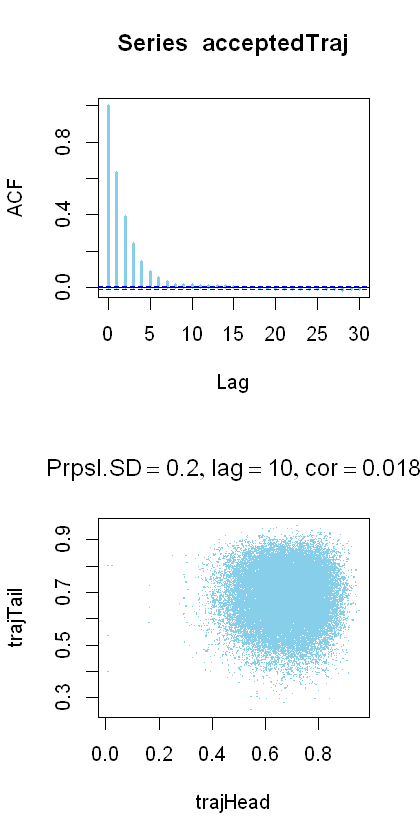

In [18]:
# creates an empty graphics plot with height=7 and width=3.5
openGraph(height=7,width=3.5)

# sets the order of the plot on the graphics device created above
# in this case there are two plots stacked vertically
layout(matrix(1:2,nrow=2))

# calculates and plots the autocorrelation function
# (in the top plot as specified in the "layout command")
acf(acceptedTraj, lag.max=30, col="skyblue", lwd=3)

# gets the length of the trajectory
Len <- length( acceptedTraj)

# sets the lag we are looking at
Lag <-10

# gets the first part of the trajectory until Len-Lag
trajHead <- acceptedTraj[1 : (Len-Lag)]

# gets the last part of the trajectory from 1+Lag until the end
trajTail <- acceptedTraj[(1+Lag) : Len]

# plots the head vs the tail of the trajectory to see if there is
# any correlation between the points after 10 jumps in the trajectory
# low correlation is better
plot(trajHead, trajTail, pch=".", col="skyblue", main=bquote(list( "Prpsl.SD" == .(proposalSD), lag == .(Lag), cor == .(round(cor(trajHead,trajTail),3)))) )